<a href="https://colab.research.google.com/github/Ajack-s/Aether/blob/main/Wan2.1_T2I_jupyter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
%cd /content
!git clone https://github.com/comfyanonymous/ComfyUI /content/ComfyUI
!git clone https://github.com/city96/ComfyUI-GGUF /content/ComfyUI/custom_nodes/ComfyUI-GGUF
!pip install torchsde gguf

!apt install aria2 -qqy
!aria2c --console-log-level=error -c -x 16 -s 16 -k 1M https://huggingface.co/city96/Wan2.1-T2V-14B-gguf/resolve/main/wan2.1-t2v-14b-Q3_K_S.gguf -d /content/ComfyUI/models/unet -o wan2.1-t2v-14b-Q3_K_M.gguf
!aria2c --console-log-level=error -c -x 16 -s 16 -k 1M https://huggingface.co/city96/umt5-xxl-encoder-gguf/resolve/main/umt5-xxl-encoder-Q3_K_S.gguf -d /content/ComfyUI/models/clip -o umt5-xxl-encoder-Q3_K_M.gguf
!aria2c --console-log-level=error -c -x 16 -s 16 -k 1M https://huggingface.co/Comfy-Org/Wan_2.1_ComfyUI_repackaged/resolve/main/split_files/vae/wan_2.1_vae.safetensors -d /content/ComfyUI/models/vae -o/wan_2.1_vae.safetensors
!aria2c --console-log-level=error -c -x 16 -s 16 -k 1M https://huggingface.co/vrgamedevgirl84/Wan14BT2VFusioniX/resolve/main/FusionX_LoRa/Wan2.1_T2V_14B_FusionX_LoRA.safetensors -d /content/ComfyUI/models/loras/FusionX -o Wan2.1_T2V_14B_FusionX_LoRA.safetensors

/content
fatal: destination path '/content/ComfyUI' already exists and is not an empty directory.
Cloning into '/content/ComfyUI/custom_nodes/ComfyUI-GGUF'...
remote: Enumerating objects: 814, done.
remote: Counting objects: 100% (508/508), done.
remote: Compressing objects: 100% (196/196), done.
remote: Total 814 (delta 458), reused 312 (delta 312), pack-reused 306 (from 2)
Receiving objects: 100% (814/814), 189.66 KiB | 863.00 KiB/s, done.
Resolving deltas: 100% (543/543), done.
aria2 is already the newest version (1.36.0-1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.

Download Results:
gid   |stat|avg speed  |path/URI
======+====+===========+=======================================================
b5f826|OK  |       0B/s|/content/ComfyUI/models/unet/wan2.1-t2v-14b-Q3_K_M.gguf

Status Legend:
(OK):download completed.

Download Results:
gid   |stat|avg speed  |path/URI
======+====+===========+=======================================================
e2b5cf|OK  |     

In [12]:
%cd /content/ComfyUI

import torch
import random, time
from PIL import Image
import numpy as np
import sys
import os

import nodes # Import the module itself
from comfy_extras import nodes_hunyuan, nodes_model_advanced

# First, ensure the custom_nodes directory is in sys.path
sys.path.insert(0, os.path.join(os.getcwd(), "custom_nodes"))

# Import the custom node module. This will execute its nodes.py and define its own NODE_CLASS_MAPPINGS.
import ComfyUI_GGUF.nodes

# Manually merge the custom node's NODE_CLASS_MAPPINGS into the main nodes.NODE_CLASS_MAPPINGS
# This ensures that nodes.NODE_CLASS_MAPPINGS contains the custom nodes.
nodes.NODE_CLASS_MAPPINGS.update(ComfyUI_GGUF.nodes.NODE_CLASS_MAPPINGS)

# Now, nodes.NODE_CLASS_MAPPINGS should contain the GGUF nodes.
# Refer to NODE_CLASS_MAPPINGS via the 'nodes' module to ensure it's always the most up-to-date version.
UnetLoaderGGUF = nodes.NODE_CLASS_MAPPINGS["UnetLoaderGGUF"]()
CLIPLoaderGGUF = nodes.NODE_CLASS_MAPPINGS["CLIPLoaderGGUF"]()
LoraLoaderModelOnly = nodes.NODE_CLASS_MAPPINGS["LoraLoaderModelOnly"]()
VAELoader = nodes.NODE_CLASS_MAPPINGS["VAELoader"]()

CLIPTextEncode = nodes.NODE_CLASS_MAPPINGS["CLIPTextEncode"]()
# Corrected: Access EmptyHunyuanLatentVideo directly from the module as it doesn't use NODE_CLASS_MAPPINGS
EmptyHunyuanLatentVideo = nodes_hunyuan.EmptyHunyuanLatentVideo()

KSampler = nodes.NODE_CLASS_MAPPINGS["KSampler"]()
ModelSamplingSD3 = nodes_model_advanced.NODE_CLASS_MAPPINGS["ModelSamplingSD3"]()
VAEDecode = nodes.NODE_CLASS_MAPPINGS["VAEDecode"]()

with torch.inference_mode():
    unet = UnetLoaderGGUF.load_unet("wan2.1-t2v-14b-Q3_K_M.gguf")[0]
    clip = CLIPLoaderGGUF.load_clip("umt5-xxl-encoder-Q3_K_M.gguf", "wan")[0]
    lora = LoraLoaderModelOnly.load_lora_model_only(unet, "FusionX/Wan2.1_T2V_14B_FusionX_LoRA.safetensors", 1.0)[0]
    vae = VAELoader.load_vae("wan_2.1_vae.safetensors")[0]

/content/ComfyUI


In [ ]:
import torch
import random, time
from PIL import Image
import numpy as np
import sys
import os

import nodes # Main ComfyUI nodes module
from comfy_extras import nodes_hunyuan, nodes_model_advanced # Also main ComfyUI modules

# First, ensure the custom_nodes directory is in sys.path
# This ensures Python can find 'ComfyUI-GGUF' as a package.
sys.path.insert(0, os.path.join(os.getcwd(), "custom_nodes"))

# Import the custom node module. This will execute its nodes.py and define its own NODE_CLASS_MAPPINGS.
# This assumes that 'ComfyUI_GGUF' can be imported as a package from sys.path.
import ComfyUI_GGUF.nodes

# Manually merge the custom node's NODE_CLASS_MAPPINGS into the main nodes.NODE_CLASS_MAPPINGS
# This ensures that nodes.NODE_CLASS_MAPPINGS contains the custom nodes.
nodes.NODE_CLASS_MAPPINGS.update(ComfyUI_GGUF.nodes.NODE_CLASS_MAPPINGS)
print("Successfully merged ComfyUI-GGUF custom nodes.")

# Instantiate ComfyUI node objects (these should now find the merged nodes)
UnetLoaderGGUF = nodes.NODE_CLASS_MAPPINGS["UnetLoaderGGUF"]()
CLIPLoaderGGUF = nodes.NODE_CLASS_MAPPINGS["CLIPLoaderGGUF"]()
LoraLoaderModelOnly = nodes.NODE_CLASS_MAPPINGS["LoraLoaderModelOnly"]()
VAELoader = nodes.NODE_CLASS_MAPPINGS["VAELoader"]()

CLIPTextEncode = nodes.NODE_CLASS_MAPPINGS["CLIPTextEncode"]()
EmptyHunyuanLatentVideo = nodes_hunyuan.EmptyHunyuanLatentVideo()

KSampler = nodes.NODE_CLASS_MAPPINGS["KSampler"]()
ModelSamplingSD3 = nodes_model_advanced.NODE_CLASS_MAPPINGS["ModelSamplingSD3"]()
VAEDecode = nodes.NODE_CLASS_MAPPINGS["VAEDecode"]()

with torch.inference_mode():
    # Load models
    unet = UnetLoaderGGUF.load_unet("wan2.1-t2v-14b-Q3_K_M.gguf")[0]
    clip = CLIPLoaderGGUF.load_clip("umt5-xxl-encoder-Q3_K_M.gguf", "wan")[0]
    lora = LoraLoaderModelOnly.load_lora_model_only(unet, "FusionX/Wan2.1_T2V_14B_FusionX_LoRA.safetensors", 1.0)[0]
    vae = VAELoader.load_vae("wan_2.1_vae.safetensors")[0]

    # Video generation parameters
    seed = 0
    steps = 10
    cfg = 1.0
    sampler_name = "euler"
    scheduler = "beta"
    width = 1280
    height = 720
    length = 120 # Increased to 120 frames for a 120-second video (assuming 1 frame per second)
    positive_prompt = "In a dim, candlelit medieval hall, a queen walks slowly along a corridor lined with flickering torches. The camera tracks her from behind in a long, steady tracking shot, capturing the heavy drape of her velvet gown and the echo of her footsteps. Shadows dance across the stone walls, and dust swirls in the warm volumetric light. The mood is regal, tense, and quietly suspenseful."
    negative_prompt = "色调艳丽，过曝，静态，细节模糊不清，字幕，风格，作品，画作，画面，静止，整体发灰，最差质量，低质量，JPEG压缩残留，丑陋的，残缺的，多余的手指，画得不好的手部，画得不好的脸部，畸形的，毁容的，形态畸形的肢体，手指融合，静止不动的画面，杂乱的背景，三条腿，背景人很多，倒着走"

    # Encode prompts
    positive = CLIPTextEncode.encode(clip, positive_prompt)[0]
    negative = CLIPTextEncode.encode(clip, negative_prompt)[0]

    # Patch model and generate latent image
    model = ModelSamplingSD3.patch(lora, 1.0)[0]
    latent_image = EmptyHunyuanLatentVideo.generate(width, height, length)[0]

    # Generate random seed if needed
    if seed == 0:
        random.seed(int(time.time()))
        seed = random.randint(0, 18446744073709551615)

    # KSampler
    samples = KSampler.sample(model, seed, steps, cfg, sampler_name, scheduler, positive, negative, latent_image)[0]

    # Decode and save image
    decoded = VAEDecode.decode(vae, samples)[0].detach()
    image = Image.fromarray(np.array(decoded*255, dtype=np.uint8)[0]).save(f"/content/test.png")

# Display the image
Image.fromarray(np.array(decoded*255, dtype=np.uint8)[0])

Successfully merged ComfyUI-GGUF custom nodes.


In [1]:
# Install libraries for video processing
!pip install imageio imageio-ffmpeg

/content/ComfyUI


ERROR:root:Failed to import comfy_kitchen, Error: No module named 'comfy_kitchen', fp8 and fp4 support will not be available.


Successfully merged ComfyUI-GGUF custom nodes.


  0%|          | 0/10 [00:00<?, ?it/s]

Decoded frames shape: (29, 720, 1280, 3)
Min value in decoded frames: 0.0
Max value in decoded frames: 1.0
First frame saved to /content/first_frame_visual_check.png for inspection.
Video saved to /content/output_video.mp4


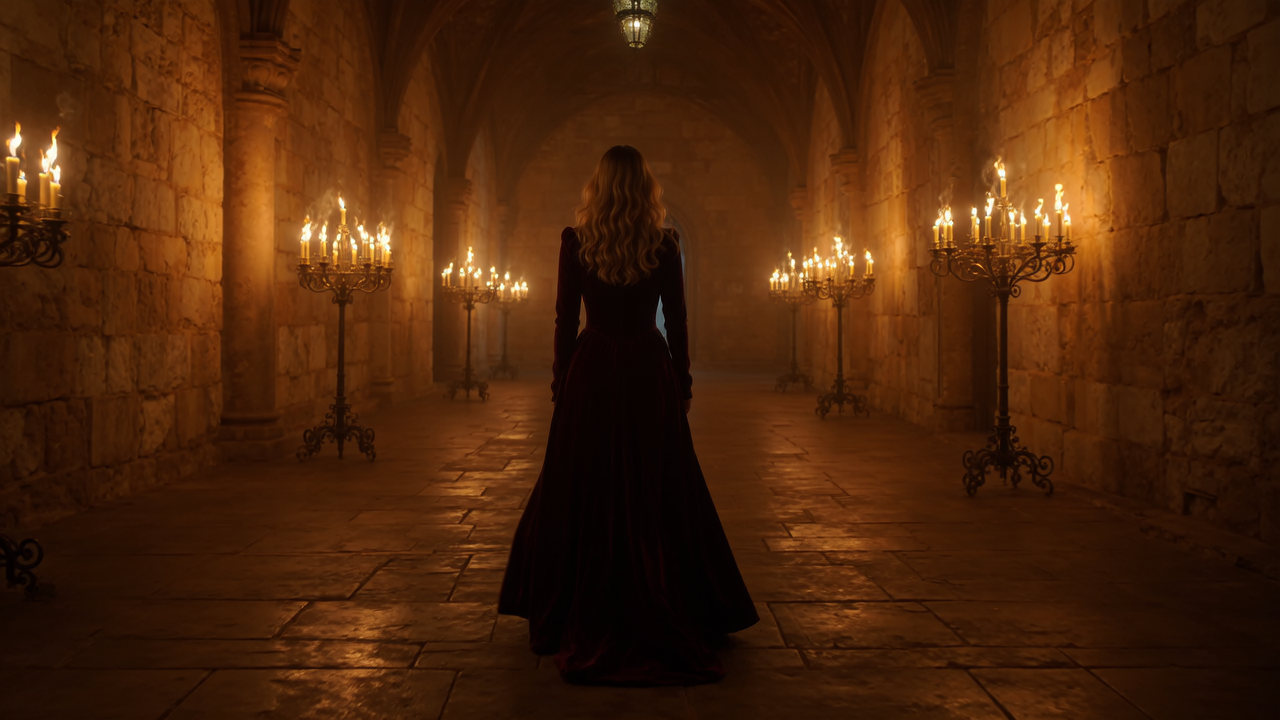

In [1]:
%cd /content/ComfyUI

import torch
import random, time
from PIL import Image
import numpy as np
import sys
import os
import imageio # Import imageio for video creation

import nodes # Main ComfyUI nodes module
from comfy_extras import nodes_hunyuan, nodes_model_advanced # Also main ComfyUI modules

# First, ensure the custom_nodes directory is in sys.path
# This ensures Python can find 'ComfyUI-GGUF' as a package.
sys.path.insert(0, os.path.join(os.getcwd(), "custom_nodes"))

# Import the custom node module. This will execute its nodes.py and define its own NODE_CLASS_MAPPINGS.
# This assumes that 'ComfyUI_GGUF' can be imported as a package from sys.path.
import ComfyUI_GGUF.nodes

# Manually merge the custom node's NODE_CLASS_MAPPINGS into the main nodes.NODE_CLASS_MAPPINGS
# This ensures that nodes.NODE_CLASS_MAPPINGS contains the custom nodes.
nodes.NODE_CLASS_MAPPINGS.update(ComfyUI_GGUF.nodes.NODE_CLASS_MAPPINGS)
print("Successfully merged ComfyUI-GGUF custom nodes.")

# Instantiate ComfyUI node objects (these should now find the merged nodes)
UnetLoaderGGUF = nodes.NODE_CLASS_MAPPINGS["UnetLoaderGGUF"]()
CLIPLoaderGGUF = nodes.NODE_CLASS_MAPPINGS["CLIPLoaderGGUF"]()
LoraLoaderModelOnly = nodes.NODE_CLASS_MAPPINGS["LoraLoaderModelOnly"]()
VAELoader = nodes.NODE_CLASS_MAPPINGS["VAELoader"]()

CLIPTextEncode = nodes.NODE_CLASS_MAPPINGS["CLIPTextEncode"]()
EmptyHunyuanLatentVideo = nodes_hunyuan.EmptyHunyuanLatentVideo()

KSampler = nodes.NODE_CLASS_MAPPINGS["KSampler"]()
ModelSamplingSD3 = nodes_model_advanced.NODE_CLASS_MAPPINGS["ModelSamplingSD3"]()
VAEDecode = nodes.NODE_CLASS_MAPPINGS["VAEDecode"]()

with torch.inference_mode():
    # Load models
    unet = UnetLoaderGGUF.load_unet("wan2.1-t2v-14b-Q3_K_M.gguf")[0]
    clip = CLIPLoaderGGUF.load_clip("umt5-xxl-encoder-Q3_K_M.gguf", "wan")[0]
    lora = LoraLoaderModelOnly.load_lora_model_only(unet, "FusionX/Wan2.1_T2V_14B_FusionX_LoRA.safetensors", 1.0)[0]
    vae = VAELoader.load_vae("wan_2.1_vae.safetensors")[0]

    # Video generation parameters
    seed = 0
    steps = 10
    cfg = 1.0
    sampler_name = "euler"
    scheduler = "beta"
    width = 1280
    height = 720
    length = 30 # Increased to 120 frames for a 15-second video (assuming 8 fps)
    positive_prompt = "In a dim, candlelit medieval hall, a queen walks slowly along a corridor lined with flickering torches. The camera tracks her from behind in a long, steady tracking shot, capturing the heavy drape of her velvet gown and the echo of her footsteps. Shadows dance across the stone walls, and dust swirls in the warm volumetric light. The mood is regal, tense, and quietly suspenseful."
    negative_prompt = "色调艳丽，过曝，静态，细节模糊不清，字幕，风格，作品，画作，画面，静止，整体发灰，最差质量，低质量，JPEG压缩残留，丑陋的，残缺的，多余的手指，画得不好的手部，画得不好的脸部，畸形的，毁容的，形态畸形的肢体，手指融合，静止不动的画面，杂乱的背景，三条腿，背景人很多，倒着走"

    # Encode prompts
    positive = CLIPTextEncode.encode(clip, positive_prompt)[0]
    negative = CLIPTextEncode.encode(clip, negative_prompt)[0]

    # Patch model and generate latent image
    model = ModelSamplingSD3.patch(lora, 1.0)[0]
    latent_image = EmptyHunyuanLatentVideo.generate(width, height, length)[0]

    # Generate random seed if needed
    if seed == 0:
        random.seed(int(time.time()))
        seed = random.randint(0, 18446744073709551615)

    # KSampler
    samples = KSampler.sample(model, seed, steps, cfg, sampler_name, scheduler, positive, negative, latent_image)[0]

    # Decode all frames
    decoded_frames = VAEDecode.decode(vae, samples)[0].detach().cpu().numpy()

    # --- Debugging: Check decoded frames content ---
    print(f"Decoded frames shape: {decoded_frames.shape}")
    print(f"Min value in decoded frames: {decoded_frames.min()}")
    print(f"Max value in decoded frames: {decoded_frames.max()}")

    # Normalize to 0-255 and convert to uint8
    video_frames = (decoded_frames * 255).astype(np.uint8)

    # Save the first frame as an image to inspect
    Image.fromarray(video_frames[0]).save("/content/first_frame_visual_check.png")
    print("First frame saved to /content/first_frame_visual_check.png for inspection.")
    # --- End Debugging ---

    # Save frames as a video
    output_video_path = "/content/output_video.mp4"
    fps = 8 # Assuming 15 seconds for 120 frames (120 frames / 15 seconds = 8 fps)
    imageio.mimwrite(output_video_path, video_frames, fps=fps, codec='libx264', quality=8, macro_block_size=1)

    print(f"Video saved to {output_video_path}")

# Display the first frame as a preview (optional)
if len(video_frames) > 0:
    display(Image.fromarray(video_frames[0]))

In [3]:
import os

output_video_path = "/content/output_video.mp4"

if os.path.exists(output_video_path):
    file_size = os.path.getsize(output_video_path)
    print(f"Video file '{output_video_path}' exists. Size: {file_size} bytes.")
    if file_size == 0:
        print("The video file exists but is empty. There might have been an issue during writing.")
    else:
        print("The video file exists and is not empty. There might be an issue with playback or encoding.")
        # Optional: Try to display the video if it's not empty
        from IPython.display import Video, display
        display(Video(output_video_path))
else:
    print(f"Video file '{output_video_path}' does not exist. The video generation likely failed.")

Video file '/content/output_video.mp4' exists. Size: 2198573 bytes.
The video file exists and is not empty. There might be an issue with playback or encoding.
